# Quick, Draw! — Data Exploration

Print the **head** of the 3 project classes (`cat`, `apple`, `car`).

The per-category `.bin` files are downloaded on first run by the [`quickdraw`](https://quickdraw.readthedocs.io) package (via the helpers in [`data_import.py`](data_import.py)) and cached under `data/binary/`.

In [2]:
import sys
from pathlib import Path

import pandas as pd

# Make src/ importable whether the kernel starts at the repo root or in src/.
here = Path.cwd()
src_dir = here / "src" if (here / "src" / "data_import.py").exists() else here
sys.path.insert(0, str(src_dir))

from data_import import CLASSES, load_group, drawing_to_record

CLASSES

['cat', 'apple', 'car']

## Load the classes

Each `QuickDrawDataGroup` downloads its category's `.bin` on first use, then reads from the cache. We load a sample of each class into a `pandas` DataFrame of drawing metadata.

In [3]:
SAMPLE = 100  # drawings loaded per class (the full .bin is still cached)

frames = {}
for name in CLASSES:
    group = load_group(name, max_drawings=SAMPLE)
    frames[name] = pd.DataFrame(drawing_to_record(d) for d in group.drawings)

{name: df.shape for name, df in frames.items()}

loading cat drawings
load complete
loading apple drawings
load complete
loading car drawings
load complete


{'cat': (100, 5), 'apple': (100, 5), 'car': (100, 5)}

## Head of each class

In [4]:
from IPython.display import display

for name, df in frames.items():
    print(f"=== {name} ===")
    display(df.head())

=== cat ===


,key_id,country,recognized,timestamp,strokes
0,5201136883597312,VE,True,1488497110,9
1,4647694628814848,BR,True,1490553834,10
2,6411036099870720,RO,True,1489829768,15
3,6196755135725568,US,True,1485360351,13
4,4597292839469056,ID,True,1485657736,9


=== apple ===


,key_id,country,recognized,timestamp,strokes
0,6420579601088512,US,False,1489184277,6
1,4986110117675008,RU,True,1488954584,2
2,6489082920173568,GB,True,1489149693,2
3,4587619411296256,US,True,1489687314,1
4,5198601426829312,TH,True,1490798117,3


=== car ===


,key_id,country,recognized,timestamp,strokes
0,4819414685843456,PH,True,1488334911,3
1,6193826576203776,CA,True,1490828909,8
2,5064695469834240,SA,False,1489169914,8
3,5648885127053312,TR,True,1490808234,5
4,4858658959654912,GB,True,1489779842,3


## A sample sketch per class

`quickdraw` renders each drawing to a PIL image, so we can eyeball one sketch from every class.

loading cat drawings
load complete
loading apple drawings
load complete
loading car drawings
load complete


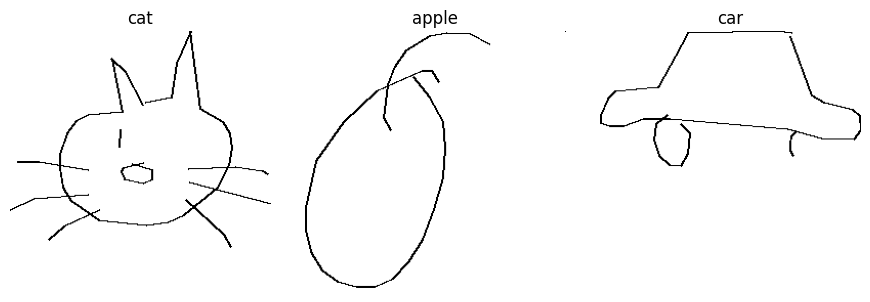

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(CLASSES), figsize=(9, 3))
for ax, name in zip(axes, CLASSES):
    drawing = load_group(name, max_drawings=1).get_drawing(index=0)
    ax.imshow(drawing.image, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()